In [1]:
import os
import sys

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["PYTORCH_ALLOC_CONF"] = (
    "expandable_segments:True,garbage_collection_threshold:0.6"
)

https://huggingface.co/docs/transformers/en/model_doc/sam3_tracker_video#video-batch-processing-for-multiple-objects

In [2]:
sys.path.append("../")
sys.path.append("../src/")

In [3]:
from transformers import Sam3TrackerVideoModel, Sam3TrackerVideoProcessor
from transformers.video_utils import load_video
from accelerate import Accelerator
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image
import numpy as np


from src.sam3_hf_video_tracking import overlay_masks_on_frame

In [4]:
device = Accelerator().device
print(f"Using device: {device}")
model = Sam3TrackerVideoModel.from_pretrained("facebook/sam3").to(
    device, dtype=torch.bfloat16
)
processor = Sam3TrackerVideoProcessor.from_pretrained("facebook/sam3")

Using device: cuda


Loading weights:   0%|          | 0/845 [00:00<?, ?it/s]

In [5]:
video_frames, _ = load_video("../data/video/test_10_sec.mp4")

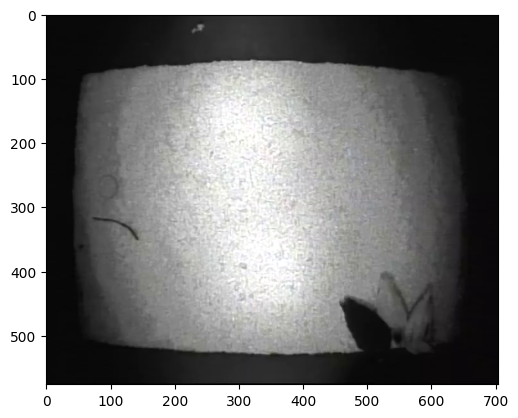

In [6]:
plt.imshow(video_frames[0])

In [7]:
def preview_input_points(
    image, input_points, input_labels, obj_ids=None, ax=None, title=None
):
    """Preview SAM3-style input points on a single frame."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    h, w = image.shape[:2]
    ax.imshow(image)
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    if title:
        ax.set_title(title)

    # Expect batch size 1: [objects][points][xy] and [objects][labels]
    points_per_obj = input_points[0] if input_points else []
    labels_per_obj = input_labels[0] if input_labels else []
    if obj_ids is None:
        obj_ids = list(range(len(points_per_obj)))

    for obj_idx, (pts, labs) in enumerate(zip(points_per_obj, labels_per_obj)):
        oid = obj_ids[obj_idx] if obj_idx < len(obj_ids) else obj_idx
        for (x, y), lab in zip(pts, labs):
            color = "lime" if lab == 1 else "red"
            marker = "o" if lab == 1 else "x"
            ax.scatter(x, y, c=color, marker=marker, s=80, linewidths=2)
        if pts:
            ax.text(
                pts[0][0],
                pts[0][1],
                f"ID {oid}",
                color="yellow",
                fontsize=9,
                weight="bold",
            )
    return ax

***

In [8]:
# from ipywidgets import Output, Button, HBox, VBox, Label, RadioButtons, IntText
# from IPython.display import display, clear_output
# import matplotlib.pyplot as plt


# class Sam3PointCollector:
#     """Interactive SAM3 point collector using ipywidgets (SSH-friendly)."""

#     def __init__(self, image, frame_idx=0, start_obj_id=0):
#         self.image = image
#         self.frame_idx = frame_idx
#         self.current_obj = start_obj_id
#         self.points_by_obj = {}
#         self.labels_by_obj = {}
#         self.h, self.w = image.shape[:2]
#         self.fig = None
#         self.ax = None
#         self.preview_scatter = None

#         # Create widgets
#         self.output = Output()
#         self.info = Label(value=f"Current Object ID: {self.current_obj}")
#         self.obj_id_input = IntText(value=self.current_obj, description="Obj ID:")
#         self.label_radio = RadioButtons(
#             options=[("Positive (fg)", 1), ("Negative (bg)", 0)],
#             value=1,
#             description="Point type:",
#         )
#         self.x_input = IntText(description="X:", value=0)
#         self.y_input = IntText(description="Y:", value=0)
#         self.add_btn = Button(description="Add Point", button_style="success")
#         self.undo_btn = Button(description="Undo", button_style="warning")
#         self.finish_btn = Button(description="Finish", button_style="info")

#         # Connect events
#         self.add_btn.on_click(self._add_point)
#         self.undo_btn.on_click(self._undo)
#         self.finish_btn.on_click(self._finish)
#         self.obj_id_input.observe(self._obj_changed, names="value")
#         self.x_input.observe(self._coords_changed, names="value")
#         self.y_input.observe(self._coords_changed, names="value")

#         # Layout
#         controls = VBox(
#             [
#                 self.info,
#                 self.obj_id_input,
#                 self.label_radio,
#                 HBox([self.x_input, self.y_input]),
#                 HBox([self.add_btn, self.undo_btn, self.finish_btn]),
#             ]
#         )
#         self.ui = HBox([self.output, controls])

#         # Initial draw
#         self._draw()

#     def _obj_changed(self, change):
#         self.current_obj = change["new"]
#         self.info.value = f"Current Object ID: {self.current_obj}"
#         self._draw()

#     def _coords_changed(self, change):
#         """Update preview marker when coordinates change."""
#         self._update_preview()

#     def _add_point(self, btn):
#         x, y = self.x_input.value, self.y_input.value
#         if not (0 <= x < self.w and 0 <= y < self.h):
#             self.info.value = f"Error: point ({x}, {y}) out of bounds!"
#             return
#         lab = self.label_radio.value
#         self.points_by_obj.setdefault(self.current_obj, []).append([x, y])
#         self.labels_by_obj.setdefault(self.current_obj, []).append(lab)
#         self.info.value = f"Added {'positive' if lab == 1 else 'negative'} point to Object {self.current_obj}"
#         self._draw()

#     def _undo(self, btn):
#         if (
#             self.current_obj in self.points_by_obj
#             and self.points_by_obj[self.current_obj]
#         ):
#             self.points_by_obj[self.current_obj].pop()
#             self.labels_by_obj[self.current_obj].pop()
#             self.info.value = f"Undid last point for Object {self.current_obj}"
#             self._draw()
#         else:
#             self.info.value = f"No points to undo for Object {self.current_obj}"

#     def _finish(self, btn):
#         self.info.value = "Finished! Results stored in collector.results"

#     def _update_preview(self):
#         """Update the preview marker for current X,Y coordinates."""
#         if self.ax is None:
#             return

#         # Remove old preview
#         if self.preview_scatter is not None:
#             self.preview_scatter.remove()
#             self.preview_scatter = None

#         x, y = self.x_input.value, self.y_input.value
#         if 0 <= x < self.w and 0 <= y < self.h:
#             # Draw preview marker
#             self.preview_scatter = self.ax.scatter(
#                 x, y, c="cyan", marker="+", s=200, linewidths=3, alpha=0.7
#             )

#         with self.output:
#             clear_output(wait=True)
#             display(self.fig)

#     def _draw(self):
#         with self.output:
#             clear_output(wait=True)
#             self.fig, self.ax = plt.subplots(figsize=(6, 6))
#             self.ax.imshow(self.image)
#             self.ax.set_xlim(0, self.w)
#             self.ax.set_ylim(self.h, 0)
#             self.ax.set_aspect("equal")
#             self.ax.set_xlabel("x (pixels)")
#             self.ax.set_ylabel("y (pixels)")
#             self.ax.set_title(
#                 "Enter X,Y coordinates (cyan + shows preview). Click Add Point."
#             )

#             # Draw all existing points
#             for obj_id, pts in self.points_by_obj.items():
#                 labs = self.labels_by_obj[obj_id]
#                 for (x, y), lab in zip(pts, labs):
#                     color = "lime" if lab == 1 else "red"
#                     marker = "o" if lab == 1 else "x"
#                     self.ax.scatter(x, y, c=color, marker=marker, s=80, linewidths=2)
#                 if pts:
#                     self.ax.text(
#                         pts[0][0],
#                         pts[0][1],
#                         f"ID {obj_id}",
#                         color="yellow",
#                         fontsize=9,
#                         weight="bold",
#                     )

#             # Draw preview for current coordinates
#             x, y = self.x_input.value, self.y_input.value
#             if 0 <= x < self.w and 0 <= y < self.h:
#                 self.preview_scatter = self.ax.scatter(
#                     x, y, c="cyan", marker="+", s=200, linewidths=3, alpha=0.7
#                 )

#             plt.tight_layout()
#             display(self.fig)

#     @property
#     def results(self):
#         """Get SAM3-compatible inputs."""
#         obj_ids = sorted(self.points_by_obj.keys())
#         input_points = [[self.points_by_obj[oid] for oid in obj_ids]]
#         input_labels = [[self.labels_by_obj[oid] for oid in obj_ids]]
#         return self.frame_idx, obj_ids, input_points, input_labels

#     def display(self):
#         """Show the UI."""
#         display(self.ui)

### Usage Example:
```python
# Create collector
collector = Sam3PointCollector(video_frames[0], frame_idx=0, start_obj_id=2)
collector.display()

# After adding points, get the results:
frame_idx, obj_ids, input_points, input_labels = collector.results
```

In [9]:
# # Create and display the collector
# collector = Sam3PointCollector(video_frames[0], frame_idx=0, start_obj_id=0)
# collector.display()

In [10]:
# # Get the results and use them with SAM3
# frame_idx, obj_ids, input_points, input_labels = collector.results
# print(f"Frame: {frame_idx}, Objects: {obj_ids}")
# print(f"Points: {input_points}")
# print(f"Labels: {input_labels}")

***

In [11]:
obj_ids = [0, 1, 2]
input_points = [[[[500, 500]], [[540, 460]], [[590, 460]]]]
input_labels = [[[1], [1], [1]]]

<Axes: title={'center': 'SAM3 input points preview'}, xlabel='x (pixels)', ylabel='y (pixels)'>

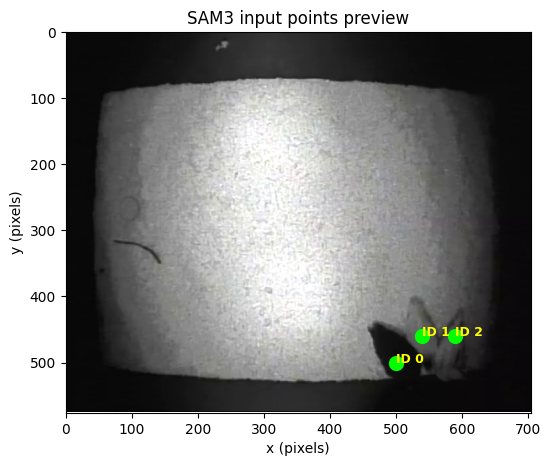

In [12]:
ann_frame_idx = 0

preview_input_points(
    video_frames[0],
    input_points,
    input_labels,
    obj_ids=obj_ids,
    title="SAM3 input points preview",
)


In [13]:
# Initialize video session
inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
    dtype=torch.bfloat16,
)

In [14]:
# Add inputs to the session
processor.add_inputs_to_inference_session(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=obj_ids,
    input_points=input_points,
    input_labels=input_labels,
)

In [15]:
# Get masks for all objects on the first frame
outputs = model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = processor.post_process_masks(
    [outputs.pred_masks],
    original_sizes=[[inference_session.video_height, inference_session.video_width]],
    binarize=False,
)[0]
print(f"Generated masks for {video_res_masks.shape[0]} objects")

Generated masks for 3 objects


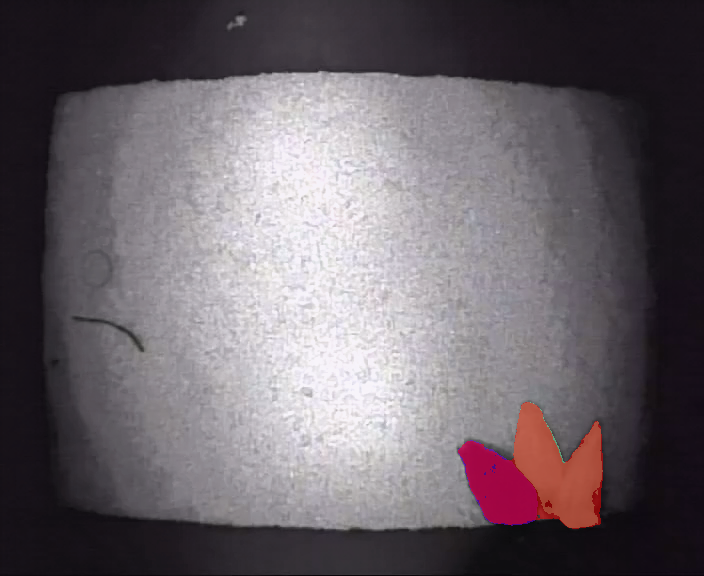

In [16]:
overlay_masks_on_frame(video_frames[0], video_res_masks)

In [17]:
inference_session.reset_inference_session()

In [18]:
ann_frame_idx = 0
obj_ids = [0, 1, 2]
input_points = [[[[500, 500]], [[540, 460]], [[590, 460]]]]
input_labels = [[[1], [1], [1]]]

inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
    dtype=torch.bfloat16,
)
processor.add_inputs_to_inference_session(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=obj_ids,
    input_points=input_points,
    input_labels=input_labels,
)

outputs = model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)

# Propagate all objects through the video
# video_segments = {}
# for sam3_tracker_video_output in tqdm(
#     model.propagate_in_video_iterator(inference_session)
# ):
#     video_res_masks = processor.post_process_masks(
#         [sam3_tracker_video_output.pred_masks],
#         original_sizes=[
#             [inference_session.video_height, inference_session.video_width]
#         ],
#         binarize=False,
#     )[0]
#     video_segments[sam3_tracker_video_output.frame_idx] = {
#         obj_id: video_res_masks[i] for i, obj_id in enumerate(inference_session.obj_ids)
#     }

# print(
#     f"Tracked {len(inference_session.obj_ids)} objects through {len(video_segments)} frames"
# )
video_segments = {}
for sam3_tracker_video_output in model.propagate_in_video_iterator(
    inference_session, show_progress_bar=True
):
    ann_frame_idx = sam3_tracker_video_output.frame_idx
    video_segments[ann_frame_idx] = sam3_tracker_video_output

print(
    f"Tracked {len(inference_session.obj_ids)} objects through {len(video_segments)} frames"
)

propagate in video: 100%|██████████| 235/235 [00:36<00:00,  6.44it/s]

Tracked 3 objects through 235 frames


In [19]:
video_segments

{0: Sam3TrackerVideoSegmentationOutput(object_ids=[0, 1, 2], pred_masks=tensor([[[[-17.6250, -20.8750, -17.7500,  ..., -21.5000, -18.1250, -18.8750],
           [-19.2500, -20.1250, -18.5000,  ..., -22.5000, -20.0000, -19.0000],
           [-19.0000, -22.1250, -18.1250,  ..., -25.5000, -22.0000, -25.5000],
           ...,
           [-16.5000, -19.8750, -17.5000,  ..., -14.9375, -12.0000, -13.1875],
           [-18.8750, -21.0000, -19.1250,  ..., -19.6250, -16.0000, -17.2500],
           [-15.3125, -17.0000, -14.3125,  ..., -14.6875, -11.6875, -12.8750]]],
 
 
         [[[-16.2500, -18.8750, -16.2500,  ..., -18.0000, -15.3750, -15.9375],
           [-17.5000, -18.2500, -16.8750,  ..., -19.7500, -17.6250, -16.2500],
           [-16.8750, -18.7500, -16.3750,  ..., -19.3750, -18.8750, -20.5000],
           ...,
           [-17.0000, -19.0000, -17.3750,  ..., -11.8125, -10.3125, -10.4375],
           [-18.2500, -20.6250, -18.0000,  ..., -12.4375, -12.2500, -12.3125],
           [-14.6250, 

In [20]:
inference_session.reset_inference_session()

In [ ]:
import cv2


def from_segmentation_output_create_annotated_video(
    video_frames, video_segments, output_path, fps=25
):
    """
    From output dict, where keys are frame idxs and values are per-frame Sam3TrackerVideoSegmentationOutput objects, create annotated video with object IDs, masks, and bboxes.

    Args:
        video_frames: List of frames (H, W, 3) numpy arrays
        video_segments: Dict[frame_idx -> Sam3TrackerVideoSegmentationOutput]
        output_path: Path to save annotated video
        fps: Frames per second for output video
    """
    # Get video dimensions from first frame
    h, w = video_frames[0].shape[:2]

    # Initialize video writer
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    # Color palette for objects (BGR format for OpenCV)
    colors = [
        (255, 0, 0),  # Blue
        (0, 255, 0),  # Green
        (0, 0, 255),  # Red
        (255, 255, 0),  # Cyan
        (255, 0, 255),  # Magenta
        (0, 255, 255),  # Yellow
    ]

    for frame_idx, frame in enumerate(video_frames):
        # Convert RGB to BGR for OpenCV
        annotated = cv2.cvtColor(frame.copy(), cv2.COLOR_RGB2BGR)

        if frame_idx in video_segments:
            seg_output = video_segments[frame_idx]

            # Post-process masks
            masks = processor.post_process_masks(
                [seg_output.pred_masks],
                original_sizes=[[h, w]],
                binarize=True,
            )[0]

            # Convert to numpy
            if masks.dtype == torch.bfloat16:
                masks = masks.float()
            masks = masks.cpu().numpy().squeeze()

            # Handle single mask case
            if masks.ndim == 2:
                masks = masks[np.newaxis, ...]

            # Draw each object
            for i, obj_id in enumerate(seg_output.object_ids):
                mask = masks[i].astype(np.uint8)
                color = colors[i % len(colors)]

                # Create colored overlay
                overlay = annotated.copy()
                overlay[mask > 0] = color
                annotated = cv2.addWeighted(annotated, 0.7, overlay, 0.3, 0)

                # Get bounding box from mask
                contours, _ = cv2.findContours(
                    mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )
                if contours:
                    x, y, bbox_w, bbox_h = cv2.boundingRect(contours[0])

                    # Draw bbox
                    cv2.rectangle(annotated, (x, y), (x + bbox_w, y + bbox_h), color, 2)

                    # Draw object ID
                    cv2.putText(
                        annotated,
                        f"ID: {obj_id}",
                        (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        color,
                        2,
                    )

        out.write(annotated)

    out.release()
    print(f"Saved annotated video to {output_path}")

In [ ]:
# Create annotated video
output_path = "../sandbox/annotated_tracking.mp4"
from_segmentation_output_create_annotated_video(video_frames, video_segments, output_path, fps=25)

print(
    f"Video saved! {len(video_segments)} frames annotated with {len(inference_session.obj_ids)} objects"
)

Saved annotated video to annotated_tracking.mp4
Video saved! 235 frames annotated with 0 objects
